## Imports

In [18]:
import matplotlib.pyplot as plt
import tensorflow as tf
import numpy as np
import pandas as pd

import os

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Dense,
    Activation,
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dropout,
    BatchNormalization,
    GlobalMaxPool2D,
)
from tensorflow.keras.applications import ResNet50V2

In [19]:
%matplotlib inline

In [20]:
print(tf.config.list_physical_devices("GPU"))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Utils

In [21]:
def plot_history(history, title="Model Performance"):
    _, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.plot(history.history["accuracy"], label="train")
    ax1.plot(history.history["val_accuracy"], label="validation")
    ax1.set_title(f"{title} - Accuracy")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Accuracy")
    ax1.legend()

    ax2.plot(history.history["loss"], label="train")
    ax2.plot(history.history["val_loss"], label="validation")
    ax2.set_title(f"{title} - Loss")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Loss")
    ax2.legend()

    plt.tight_layout()
    plt.show()

In [22]:
def predict_and_visualize(model, image_path, class_names, target_size=(224, 224)):
    img = tf.keras.utils.load_img(image_path, target_size=target_size)
    img_array = tf.keras.utils.img_to_array(img)
    img_batch = tf.expand_dims(img_array, 0)
    
    predictions = model.predict(img_batch, verbose=0)
    
    score = predictions[0][0] 
    
    predicted_class = class_names[1] if score > 0.5 else class_names[0]
    
    confidence = 100 * (score if score > 0.5 else 1 - score)
    
    plt.figure(figsize=(4, 4))
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Pred: {predicted_class} | Conf: {confidence:.2f}%")
    plt.show()
    
    return predicted_class, confidence

In [23]:
def predict_batch_directory(model, directory_path, class_names, batch_size=32, target_size=(224, 224)):

    inference_dataset = tf.keras.utils.image_dataset_from_directory(
        directory_path,
        labels=None,
        label_mode=None,
        batch_size=batch_size,
        image_size=target_size,
        shuffle=False
    )
    
    file_paths = inference_dataset.file_paths
    
    print(f"Running inference on {len(file_paths)} images...")
    predictions = model.predict(inference_dataset)
    
    scores = predictions.flatten() 
    
    predicted_indices = (scores > 0.5).astype(int)
    confidences = np.where(scores > 0.5, scores, 1 - scores) * 100 
    
    predicted_labels = [class_names[idx] for idx in predicted_indices]
    
    results_df = pd.DataFrame({
        'File_Path': file_paths,
        'Predicted_Class': predicted_labels,
        'Confidence_Score': confidences
    })
    
    return results_df

## EDA

In [24]:
dataset_dir = "../data/dogs_vs_cats"
train_dir = f"{dataset_dir}/train"
test_dir = f"{dataset_dir}/test"

In [25]:
print("Loading Training Data:")
train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir, image_size=(224, 224), batch_size=32
)

print("\nLoading Test/Validation Data:")
val_dataset = tf.keras.utils.image_dataset_from_directory(
    test_dir, image_size=(224, 224), batch_size=32
)

Loading Training Data:
Found 20000 files belonging to 2 classes.

Loading Test/Validation Data:
Found 5000 files belonging to 2 classes.


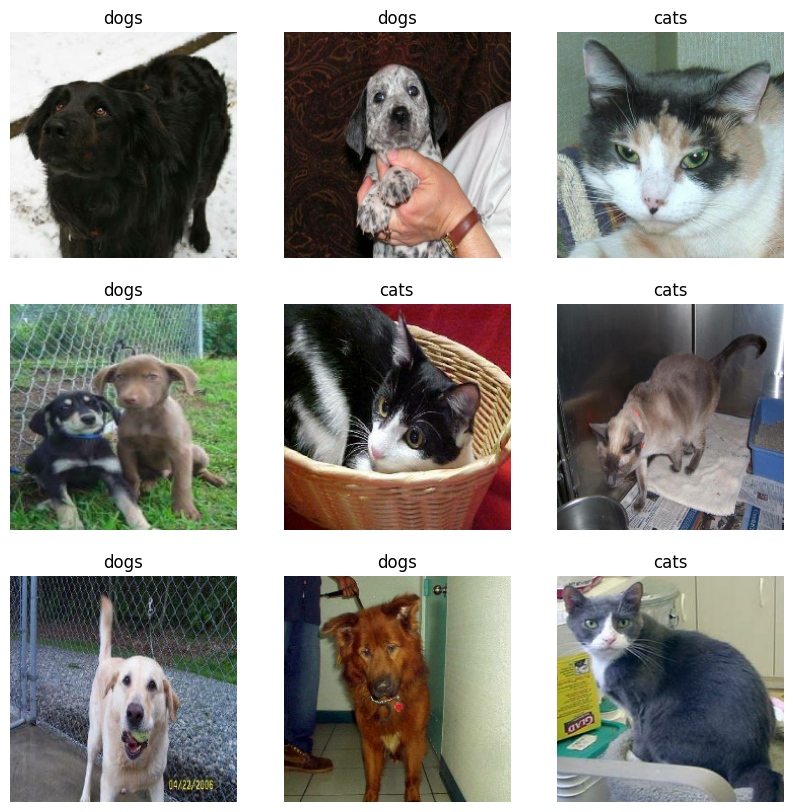

In [26]:
class_names = train_dataset.class_names

plt.figure(figsize=(10, 10))

for images, labels in train_dataset.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.show()

In [27]:
data_augmentation = tf.keras.Sequential(
    [
        tf.keras.layers.RandomFlip("horizontal"),
        tf.keras.layers.RandomRotation(0.2),
        tf.keras.layers.RandomZoom(height_factor=(-0.3, -0.2)),
    ]
)

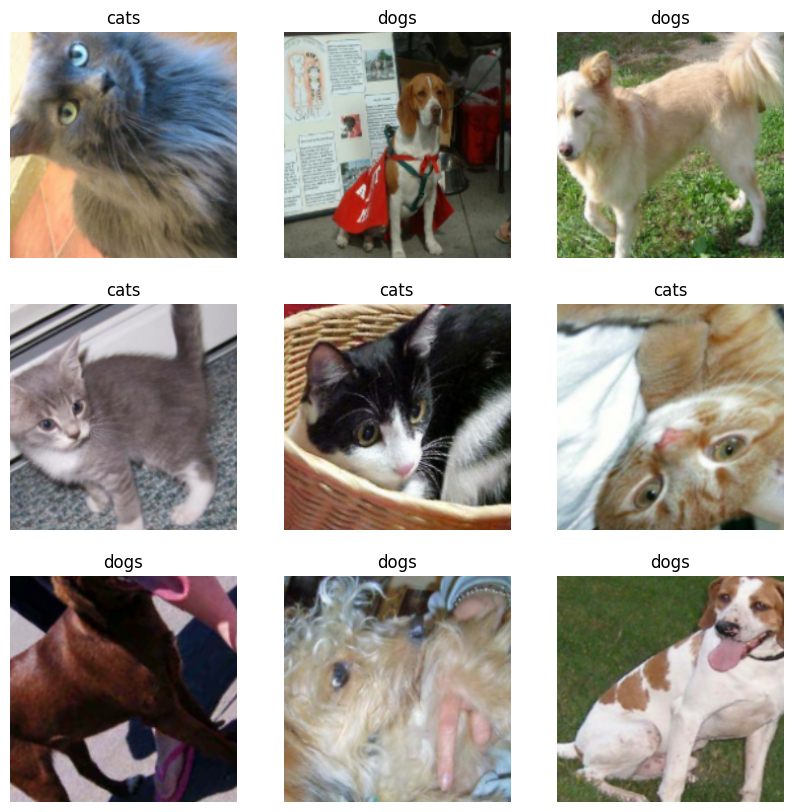

In [28]:
plt.figure(figsize=(10, 10))
for images, labels in train_dataset.take(1):
    augmented_images = data_augmentation(images)
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(augmented_images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.show()

## CNN

In [29]:
if not os.path.exists("models"):
    os.makedirs("models")

In [30]:
model = Sequential()

model.add(tf.keras.Input(shape=(224, 224, 3)))

model.add(data_augmentation)

# Normalization
model.add(tf.keras.layers.Rescaling(1./255))

# Block 1
model.add(Conv2D(filters=32, padding='same', kernel_size=(7,7))) 
model.add(Activation('relu')) 
model.add(BatchNormalization()) 
model.add(MaxPooling2D(pool_size=(2,2))) 
model.add(Dropout(0.2)) 

# Block 2
model.add(Conv2D(filters=64, padding='valid', kernel_size=(5,5))) 
model.add(Activation('relu')) 
model.add(BatchNormalization()) 
model.add(MaxPooling2D(pool_size=(2,2))) 
model.add(Dropout(0.2)) 

# Block 3
model.add(Conv2D(filters=128, padding='valid', kernel_size=(3,3))) 
model.add(Activation('relu')) 
model.add(BatchNormalization()) 
model.add(MaxPooling2D()) 
model.add(Dropout(0.2)) 

# Block 4
model.add(Conv2D(filters=256, padding='valid', kernel_size=(3,3))) 
model.add(Activation('relu')) 
model.add(BatchNormalization()) 
model.add(Conv2D(filters=256, kernel_size=(3,3))) 
model.add(Activation('relu')) 
model.add(BatchNormalization()) 
model.add(MaxPooling2D(pool_size=(2,2))) 
model.add(Dropout(0.2)) 

# Final Layers
model.add(GlobalMaxPool2D()) 
model.add(Dense(units=256)) 
model.add(Activation('relu')) 
model.add(Dropout(0.2)) 
model.add(Dense(units=1)) 
model.add(Activation('sigmoid')) 

model.summary()
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_3 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 224, 224, 32)   │         4,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_9 (Activation)       │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 108, 108, 64)   │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_10 (Activation)      │ (None, 108, 108, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 108, 108, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_11 (Activation)      │ (None, 52, 52, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 52, 52, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_12 (Activation)      │ (None, 24, 24, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 24, 24, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 22, 22, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_13 (Activation)      │ (None, 22, 22, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 22, 22, 256)    │         1,02

 Total params: 1,084,097 (4.14 MB)

 Trainable params: 1,082,625 (4.13 MB)

 Non-trainable params: 1,472 (5.75 KB)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 171s 265ms/step - accuracy: 0.5333 - loss: 1.2368 - val_accuracy: 0.5078 - val_loss: 0.9595
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 162s 259ms/step - accuracy: 0.5858 - loss: 0.8641 - val_accuracy: 0.6434 - val_loss: 0.6396
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 170s 271ms/step - accuracy: 0.6181 - loss: 0.7041 - val_accuracy: 0.5060 - val_loss: 1.0097
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 162s 260ms/step - accuracy: 0.6406 - loss: 0.6893 - val_accuracy: 0.6844 - val_loss: 0.5883
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 163s 261ms/step - accuracy: 0.6316 - loss: 0.7272 - val_accuracy: 0.5918 - val_loss: 0.7754
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 163s 261ms/step - accuracy: 0.6477 - loss: 0.7459 - val_accuracy: 0.5962 - val_loss: 0.8013
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 166s 265ms/step - accuracy: 0.6679 - loss: 0.7357 - val_accuracy: 0.5440 - val_loss: 1.2209
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 167s 267ms/step - accuracy: 0.6599 -

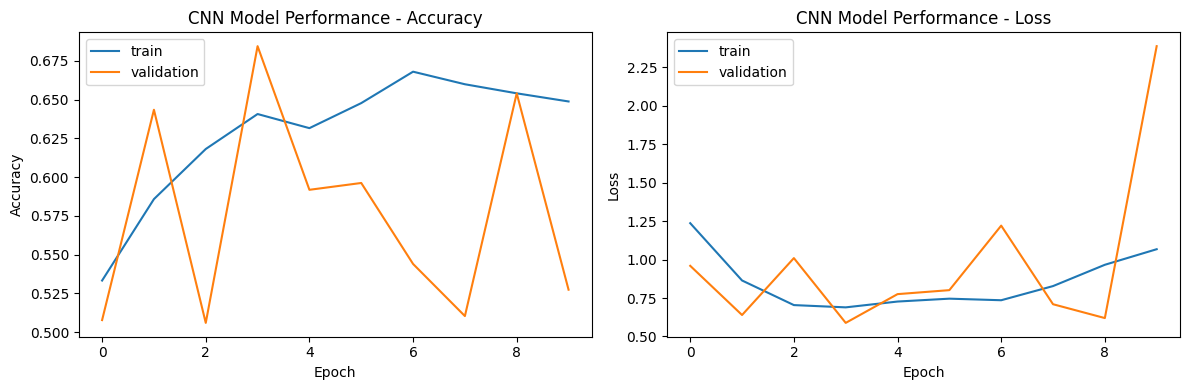

Model saved to 'models/model_cnn_cats_dogs.keras'!


In [31]:
model_path = 'models/model_cnn_cats_dogs.keras'

if os.path.exists(model_path):
    print(f"Loading model from {model_path}...")
    model = tf.keras.models.load_model(model_path)
else:
    history = model.fit(train_dataset, validation_data=val_dataset, epochs=10)
    
    loss, accuracy = model.evaluate(val_dataset)
    print(f"Validation Accuracy: {accuracy*100:.2f}%")
    
    plot_history(history, title="CNN Model Performance")
    
    model.save(model_path)
    print(f"Model saved to '{model_path}'!")

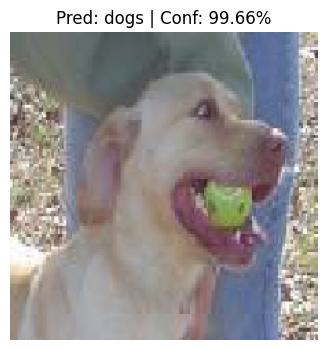

('dogs', 99.66322779655457)

In [32]:
class_names = train_dataset.class_names
random_image = np.random.choice(val_dataset.file_paths)
predict_and_visualize(model, random_image, class_names)

In [33]:
results_df = predict_batch_directory(model, test_dir, class_names)
print(results_df.head())

Found 5000 files.
Running inference on 5000 images...
157/157 ━━━━━━━━━━━━━━━━━━━━ 8s 48ms/step
                                      File_Path Predicted_Class  \
0     ../data/dogs_vs_cats/test/cats/cat.10.jpg            dogs   
1  ../data/dogs_vs_cats/test/cats/cat.10000.jpg            dogs   
2  ../data/dogs_vs_cats/test/cats/cat.10001.jpg            cats   
3  ../data/dogs_vs_cats/test/cats/cat.10007.jpg            cats   
4  ../data/dogs_vs_cats/test/cats/cat.10017.jpg            dogs   

   Confidence_Score  
0         99.987839  
1         93.580841  
2         86.445969  
3         83.526703  
4         83.737633  


In [34]:
base_model = ResNet50V2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False 

resnet_model = Sequential()
resnet_model.add(tf.keras.Input(shape=(224, 224, 3)))

resnet_model.add(tf.keras.layers.Lambda(tf.keras.applications.resnet_v2.preprocess_input))

resnet_model.add(base_model)
resnet_model.add(GlobalMaxPool2D())
resnet_model.add(Dense(units=128))
resnet_model.add(Activation("relu"))
resnet_model.add(Dropout(0.2))
resnet_model.add(Dense(units=1))
resnet_model.add(Activation("sigmoid"))

resnet_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

Training ResNet50 Comparison Model...
Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 113s 173ms/step - accuracy: 0.9757 - loss: 0.6253 - val_accuracy: 0.9858 - val_loss: 0.2955
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 106s 170ms/step - accuracy: 0.9822 - loss: 0.4070 - val_accuracy: 0.9866 - val_loss: 0.2745
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 106s 170ms/step - accuracy: 0.9833 - loss: 0.3579 - val_accuracy: 0.9856 - val_loss: 0.2616
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 100s 160ms/step - accuracy: 0.9850 - loss: 0.2822 - val_accuracy: 0.9842 - val_loss: 0.2945
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 97s 156ms/step - accuracy: 0.9852 - loss: 0.2419 - val_accuracy: 0.9858 - val_loss: 0.2040
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 97s 156ms/step - accuracy: 0.9852 - loss: 0.1964 - val_accuracy: 0.9798 - val_loss: 0.2998
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 98s 157ms/step - accuracy: 0.9882 - loss: 0.1382 - val_accuracy: 0.9884 - val_loss: 0.1246
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 9

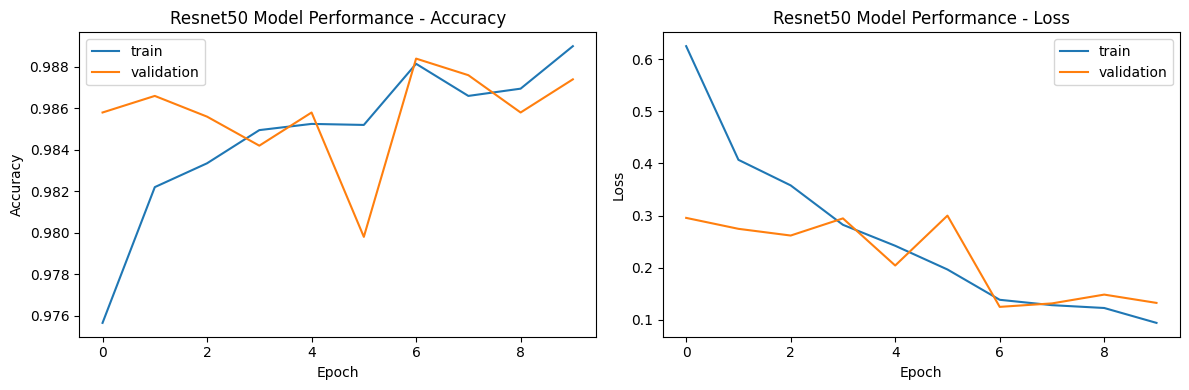

Model saved to 'models/resnet50_cats_dogs.keras'!


In [35]:
model_path = 'models/resnet50_cats_dogs.keras'

if os.path.exists(model_path):
    print(f"Loading model from {model_path}...")
    resnet_model = tf.keras.models.load_model(model_path)
else:
    
    print("Training ResNet50 Comparison Model...")
    history_resnet = resnet_model.fit(train_dataset, validation_data=val_dataset, epochs=10)
    
    loss, accuracy = resnet_model.evaluate(val_dataset)
    print(f"ResNet Validation Accuracy: {accuracy*100:.2f}%")
    
    plot_history(history_resnet, title="Resnet50 Model Performance")
    
    resnet_model.save(model_path)
    print(f"Model saved to '{model_path}'!")

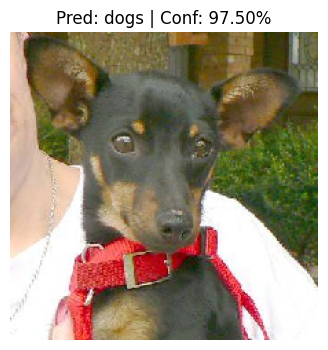

('dogs', 97.49786257743835)

In [36]:
class_names = train_dataset.class_names
random_image = np.random.choice(val_dataset.file_paths)
predict_and_visualize(model, random_image, class_names)

In [37]:
results_df = predict_batch_directory(resnet_model, test_dir, class_names)
print(results_df.head())

Found 5000 files.
Running inference on 5000 images...
157/157 ━━━━━━━━━━━━━━━━━━━━ 24s 139ms/step
                                      File_Path Predicted_Class  \
0     ../data/dogs_vs_cats/test/cats/cat.10.jpg            cats   
1  ../data/dogs_vs_cats/test/cats/cat.10000.jpg            cats   
2  ../data/dogs_vs_cats/test/cats/cat.10001.jpg            cats   
3  ../data/dogs_vs_cats/test/cats/cat.10007.jpg            cats   
4  ../data/dogs_vs_cats/test/cats/cat.10017.jpg            cats   

   Confidence_Score  
0             100.0  
1             100.0  
2             100.0  
3             100.0  
4             100.0  
